In [12]:
!git clone https://github.com/muhnatha/binary-machine-generated-code-detection.git
%cd /content/binary-machine-generated-code-detection

Cloning into 'binary-machine-generated-code-detection'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 145 (delta 77), reused 77 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 4.20 MiB | 17.61 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/content/binary-machine-generated-code-detection


In [13]:
!pip install -r requirements.txt

# Import Library

In [14]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import gc
import re
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler
from collections import Counter
from datasets import load_dataset, ClassLabel

# Konfigurasi

In [15]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

OUTPUT_DIR = "output_experiment"
MODEL_NAME = "microsoft/unixcoder-base"
MAX_LEN = 512
BATCH_SIZE = 8
ACCUMULATION_STEPS = 2
EPOCHS = 3
PATIENCE = 3
LEARNING_RATE = 2e-5
CLASS_NAMES = ['Human-Written', 'Machine-Generated']

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"Seed set to {seed}")

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Seed set to 42
Device: cuda


# Dataset Class

In [16]:
class RawCodeDataset(Dataset):
    def __init__(self, split='train', subsample=True, sample_size=5000):
        logger.info(f"Loading raw {split} dataset...")
        try:
            full_dataset = load_dataset("DaniilOr/SemEval-2026-Task13", "A", split=split)
        except Exception as e:
            logger.error(f"Failed to load dataset: {e}")
            raise

        if subsample:
            logger.info(f"Subsampling {split} to {sample_size}")
            full_dataset = full_dataset.map(lambda x: {'stratify_col': f"{x['label']}_{x['language']}"})

            try:
                full_dataset = full_dataset.class_encode_column("stratify_col")
            except AttributeError:
                full_dataset = full_dataset.cast_column("stratify_col", ClassLabel(names=list(set(full_dataset["stratify_col"]))))

            if len(full_dataset) > sample_size:
                proportion = sample_size / len(full_dataset)
                self.raw_dataset = full_dataset.train_test_split(
                    test_size=proportion,
                    shuffle=True,
                    seed=10,
                    stratify_by_column="stratify_col"
                )['test']
                self.raw_dataset = self.raw_dataset.remove_columns(['stratify_col'])
            else:
                self.raw_dataset = full_dataset
        else:
            self.raw_dataset = full_dataset

        logger.info(f"Loaded {split} with {len(self.raw_dataset)} examples")

    def __len__(self):
        return len(self.raw_dataset)

    def __getitem__(self, idx):
        item = self.raw_dataset[idx]
        return {
            'code': item['code'],
            'label': item['label'],
            'language': item['language']
        }

# AST Parser & Cleaning

In [17]:
try:
    from tree_sitter import Language, Parser
    import tree_sitter_languages
    TREE_SITTER_AVAILABLE = True
except ImportError:
    print("WARNING: tree-sitter not installed properly.")
    TREE_SITTER_AVAILABLE = False

class ASTParser:
    def __init__(self):
        self.parsers = {}
        self.lang_map = {
            'Python': 'python', 'Java': 'java', 'C++': 'cpp', 'Go': 'go',
            'PHP': 'php', 'JavaScript': 'javascript', 'C': 'c',
            'C#': 'c_sharp', 'Ruby': 'ruby'
        }

    def get_parser(self, lang_name):
        if not TREE_SITTER_AVAILABLE: return None
        ts_lang = self.lang_map.get(lang_name)
        if not ts_lang: return None

        if ts_lang not in self.parsers:
            try:
                parser = Parser()
                language = tree_sitter_languages.get_language(ts_lang)
                parser.set_language(language)
                self.parsers[ts_lang] = parser
            except Exception:
                self.parsers[ts_lang] = None
        return self.parsers[ts_lang]

    def parse_to_flattened_ast(self, code, lang_name):
        parser = self.get_parser(lang_name)
        if not parser: return ""
        try:
            tree = parser.parse(bytes(code, "utf8"))
            cursor = tree.walk()
            tokens = []
            visited_children = False
            while True:
                if not visited_children:
                    if cursor.node.is_named:
                        tokens.append(cursor.node.type)
                    if cursor.goto_first_child(): continue
                if cursor.goto_next_sibling(): visited_children = False
                elif cursor.goto_parent(): visited_children = True
                else: break
            return " ".join(tokens)
        except Exception: return ""

def clean_code_strict(code):
    if pd.isna(code) or code == '': return ''
    code = str(code)
    code = re.sub(r'<[^>]+>', '', code)
    lines = [line.rstrip() for line in code.split('\n') if line.strip()]
    return '\n'.join(lines)

# Tokenisasi & Data Loader

In [18]:
class CodeDataset(Dataset):
    def __init__(self, data_source, tokenizer, max_len, lang_weights=None):
        self.data_source = data_source
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.lang_weights = lang_weights
        self.ast_parser = ASTParser()

    def __len__(self):
        return len(self.data_source)

    def __getitem__(self, index):
        item = self.data_source[index]
        code_text = clean_code_strict(str(item['code']))
        label = item['label']
        language = item['language']

        ast_text = self.ast_parser.parse_to_flattened_ast(code_text, language)

        encoding = self.tokenizer(
            code_text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding=False,
            truncation='longest_first',
            return_tensors=None
        )

        weight = 1.0
        if self.lang_weights:
            weight = self.lang_weights.get(language, 1.0)

        return {
            'input_ids': torch.tensor(encoding['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(encoding['attention_mask'], dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float),
            'sample_weight': torch.tensor(weight, dtype=torch.float)
        }

def dynamic_collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    labels = torch.stack([item['labels'] for item in batch])
    weights = torch.stack([item['sample_weight'] for item in batch])

    input_ids_padded = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=1)
    attention_mask_padded = torch.nn.utils.rnn.pad_sequence(attention_mask, batch_first=True, padding_value=0)

    return {
        'input_ids': input_ids_padded,
        'attention_mask': attention_mask_padded,
        'labels': labels,
        'sample_weight': weights
    }

# Arsitektur Model (UniXcoder)

In [19]:
class UniXcoderClassifier(nn.Module):
    def __init__(self, base_model):
        super(UniXcoderClassifier, self).__init__()
        self.bert = base_model
        self.drop = nn.Dropout(p=0.1)
        hidden_size = self.bert.config.hidden_size
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        output = self.drop(pooled_output)
        return self.out(output)

# Fungsi Training & Evaluasi

In [20]:
def compute_language_weights(raw_data):
    langs = [item['language'] for item in raw_data]
    count = Counter(langs)
    total = len(langs)
    weights = {l: total / (len(count) * freq) for l, freq in count.items()}
    return weights

def train_epoch(model, data_loader, loss_fn, optimizer, scaler, device):
    model = model.train()
    losses = []
    optimizer.zero_grad()

    for i, d in tqdm(enumerate(data_loader), total=len(data_loader), desc="Train", leave=False):
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["labels"].to(device)
        weights = d["sample_weight"].to(device)

        with autocast():
            outputs = model(input_ids, attention_mask).view(-1)
            loss = (loss_fn(outputs, targets) * weights).mean() / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        losses.append(loss.item() * ACCUMULATION_STEPS)
    return np.mean(losses) if losses else 0

def eval_model(model, data_loader, loss_fn, device):
    model = model.eval()
    losses, preds, targets = [], [], []
    with torch.no_grad():
        for d in tqdm(data_loader, desc="Eval", leave=False):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            y = d["labels"].to(device)
            with autocast():
                out = model(input_ids, attention_mask).view(-1)
                loss = loss_fn(out, y).mean()
            losses.append(loss.item())
            preds.extend((torch.sigmoid(out) > 0.5).float().cpu().numpy())
            targets.extend(y.cpu().numpy())
    return np.mean(losses), f1_score(targets, preds, average='binary')

# Training

Initializing microsoft/unixcoder-base...
Starting Training...
Epoch 1/3


/tmp/ipython-input-1805061309.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Train:   0%|          | 0/250 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/tree_sitter/__init__.py:36: FutureWarning: Language(path, name) is deprecated. Use Language(ptr, name) instead.
  warn("{} is deprecated. Use {} instead.".format(old, new), FutureWarning)
/tmp/ipython-input-3144334627.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Eval:   0%|          | 0/63 [00:00<?, ?it/s]

...

Train:   0%|          | 0/250 [00:00<?, ?it/s]

/tmp/ipython-input-3144334627.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Eval:   0%|          | 0/63 [00:00<?, ?it/s]

/tmp/ipython-input-3144334627.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Train Loss: 0.2515 | Val Loss: 0.1441 | Val F1: 0.9589


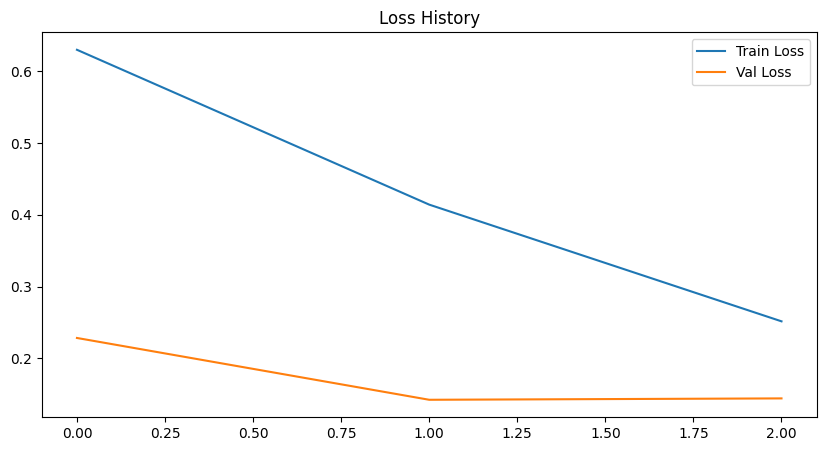

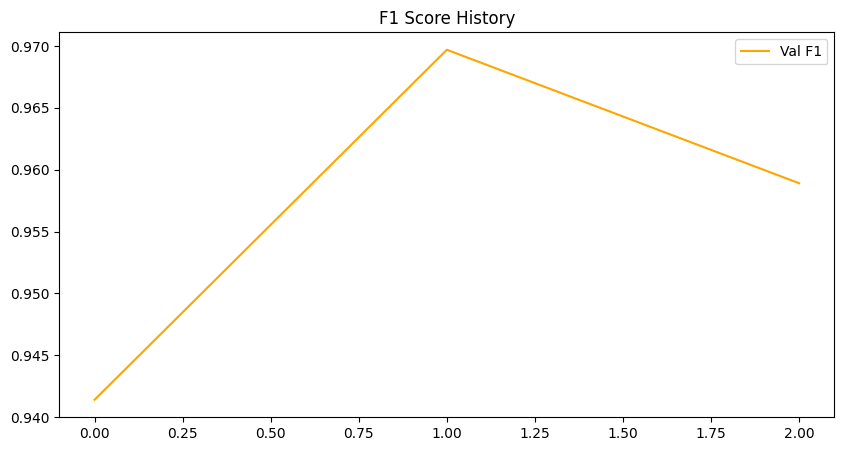

In [21]:
# 1. Load Data
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_raw = RawCodeDataset('train', subsample=True, sample_size=2000)
val_raw = RawCodeDataset('validation', subsample=True, sample_size=500)
test_raw = RawCodeDataset('test', subsample=True, sample_size=500)

train_data = [{'code': x['code'], 'label': x['label'], 'language': x['language']} for x in train_raw]
val_data = [{'code': x['code'], 'label': x['label'], 'language': x['language']} for x in val_raw]
test_data = [{'code': x['code'], 'label': x['label'], 'language': x['language']} for x in test_raw]

# 2. Compute Weights & Create Loaders
lang_weights = compute_language_weights(train_data)
train_set = CodeDataset(train_data, tokenizer, MAX_LEN, lang_weights)
val_set = CodeDataset(val_data, tokenizer, MAX_LEN)
test_set = CodeDataset(test_data, tokenizer, MAX_LEN)

train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True, collate_fn=dynamic_collate_fn)
val_loader = DataLoader(val_set, BATCH_SIZE, collate_fn=dynamic_collate_fn)
test_loader = DataLoader(test_set, BATCH_SIZE, collate_fn=dynamic_collate_fn)

# 3. Initialize Model
print(f"Initializing {MODEL_NAME}...")
base_model = AutoModel.from_pretrained(MODEL_NAME)
model = UniXcoderClassifier(base_model).to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.BCEWithLogitsLoss(reduction='none').to(device)
scaler = GradScaler()

# 4. Training Loop
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1 = 0
patience_cnt = 0
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")

print("Starting Training...")
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, scaler, device)
    val_loss, val_f1 = eval_model(model, val_loader, loss_fn, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        patience_cnt = 0
        print("  >> Saved Best Model")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print("Early stopping.")
            break

# 5. Visualisasi Hasil Training
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend(); plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['val_f1'], label='Val F1', color='orange')
plt.title('F1 Score History')
plt.legend(); plt.show()